Dataset Preview:
   hours_studied  attendance  past_score  extra_activities  pass_fail
0            2.0          70          50                 0          0
1            3.0          80          60                 1          1
2            5.0          90          75                 0          1
3            1.0          60          40                 1          0
4            4.0          85          70                 0          1
Class Distribution:
pass_fail
1    8
0    4
Name: count, dtype: int64
Model Accuracy: 75.00%
Classification Report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       1.00      0.67      0.80         3

    accuracy                           0.75         4
   macro avg       0.75      0.83      0.73         4
weighted avg       0.88      0.75      0.77         4



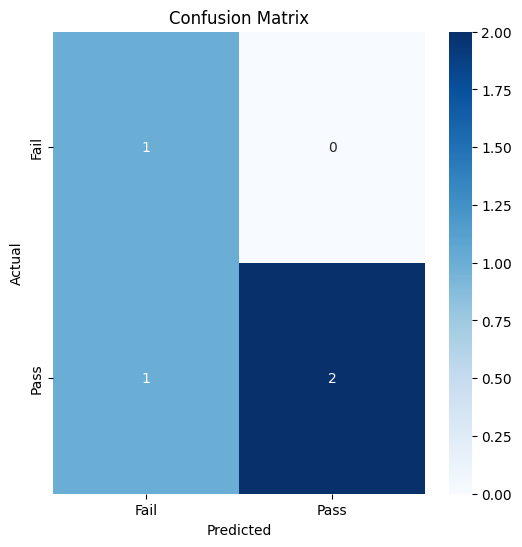

Prediction for Example Data:
The student is predicted to pass!


e:\sunny\OneDrive\Desktop\Student_Performance_Predictor_Project\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('student_data.csv')

# Display the dataset
print("Dataset Preview:")
print(df.head())

# Check the class distribution
print("Class Distribution:")
print(df['pass_fail'].value_counts())

# Handling Imbalanced Dataset (Optional Step)
# Upsample the minority class
df_majority = df[df.pass_fail == 1]
df_minority = df[df.pass_fail == 0]

df_minority_upsampled = resample(df_minority,
                                 replace=True,    # Sample with replacement
                                 n_samples=len(df_majority), # Match majority class size
                                 random_state=42) # For reproducibility

# Combine the majority class with the upsampled minority class
df_balanced = pd.concat([df_majority, df_minority_upsampled])

# Split the data into features and target
X = df_balanced[['hours_studied', 'attendance', 'past_score', 'extra_activities']]
y = df_balanced['pass_fail']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the Logistic Regression model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)

# Model Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Show classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Visualize confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Now let's test the model on new data input

# Define a function for prediction
def predict_performance(hours_studied, attendance, past_score, extra_activities):
    # Prepare the input data
    input_data = np.array([[hours_studied, attendance, past_score, extra_activities]])
    
    # Scale the input data
    scaled_input = scaler.transform(input_data)
    
    # Make prediction
    prediction = model.predict(scaled_input)
    
    if prediction == 1:
        return "The student is predicted to pass!"
    else:
        return "The student is predicted to fail."

# Test the function with some example data
print("Prediction for Example Data:")
example_prediction = predict_performance(4.5, 85, 70, 1)
print(example_prediction)
